## The Scale Paradox: Airport Volume vs Delay
Jointplot with LOWESS trend and busiest-airport highlighting to test if delay scales linearly with traffic or plateaus.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')

# Load merged dataset
possible_paths = ['../data/processed/merged_data.csv']
df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded dataset from: {path}')
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError('merged_data.csv not found in project root or data/processed/')

required = {'ORIGIN_AIRPORT', 'DEPARTURE_DELAY'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}')

# Airport-level summary
airport_stats = (
    df.groupby('ORIGIN_AIRPORT', as_index=False)
      .agg(
          flight_count=('ORIGIN_AIRPORT', 'size'),
          mean_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
      .dropna(subset=['mean_departure_delay'])
)

top10 = airport_stats.nlargest(10, 'flight_count').copy()
top10_codes = set(top10['ORIGIN_AIRPORT'])

airport_stats.head()

Loaded dataset from: ../data/processed/merged_data.csv


,ORIGIN_AIRPORT,flight_count,mean_departure_delay
0,10135,239,7.324561
1,10136,187,2.301136
2,10140,1750,5.603241
3,10141,66,1.532258
4,10146,84,5.294872


statsmodels not installed: using polynomial trend fallback instead of LOWESS.


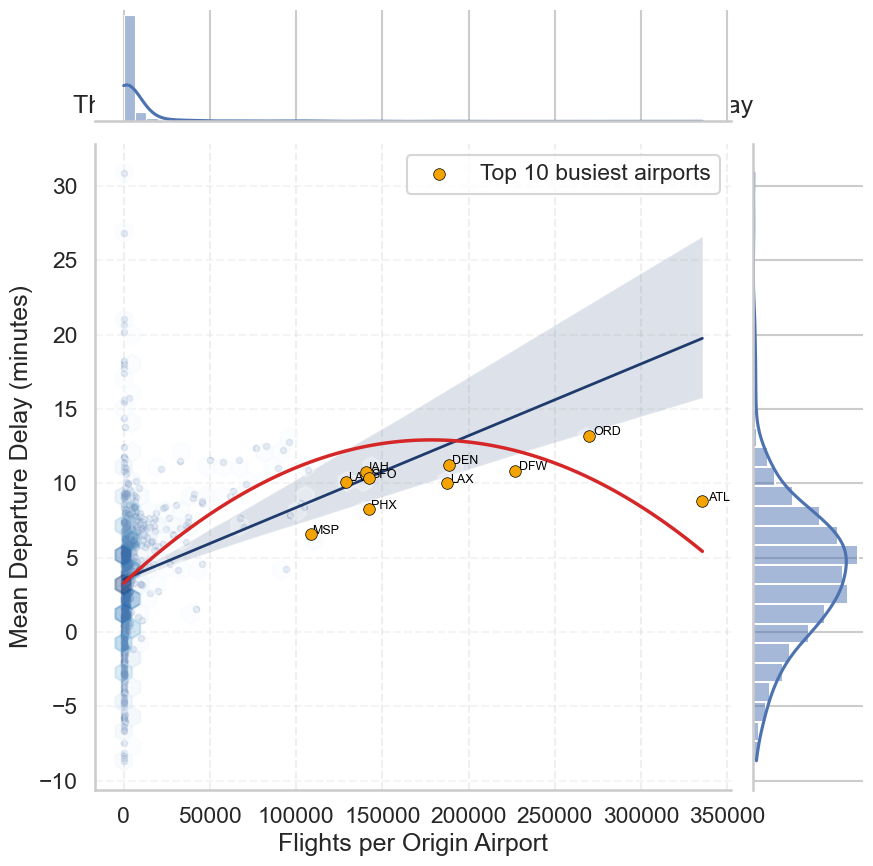

In [2]:
# Jointplot with regression + LOWESS smoother
import importlib.util

g = sns.jointplot(
    data=airport_stats,
    x='flight_count',
    y='mean_departure_delay',
    kind='reg',
    height=9,
    scatter_kws={'alpha': 0.22, 's': 20, 'color': '#5B7DB1'},
    line_kws={'color': '#1F3B6D', 'linewidth': 2}
)

# Overlay density to handle clumping among small airports
g.ax_joint.hexbin(
    airport_stats['flight_count'],
    airport_stats['mean_departure_delay'],
    gridsize=35,
    cmap='Blues',
    mincnt=1,
    alpha=0.35
)

# Add LOWESS curve to inspect non-linearity (efficiency curve)
if importlib.util.find_spec('statsmodels') is not None:
    sns.regplot(
        data=airport_stats,
        x='flight_count',
        y='mean_departure_delay',
        lowess=True,
        scatter=False,
        line_kws={'color': '#D62728', 'linewidth': 2.5, 'label': 'LOWESS'},
        ax=g.ax_joint
    )
else:
    # Fallback if statsmodels is unavailable
    sns.regplot(
        data=airport_stats,
        x='flight_count',
        y='mean_departure_delay',
        order=2,
        scatter=False,
        ci=None,
        line_kws={'color': '#D62728', 'linewidth': 2.5, 'label': 'Polynomial trend (LOWESS fallback)'},
        ax=g.ax_joint
    )
    print('statsmodels not installed: using polynomial trend fallback instead of LOWESS.')

# Highlight and label top 10 busiest airports
top10_plot = airport_stats[airport_stats['ORIGIN_AIRPORT'].isin(top10_codes)]
g.ax_joint.scatter(
    top10_plot['flight_count'],
    top10_plot['mean_departure_delay'],
    s=70,
    color='#F4A300',
    edgecolor='black',
    linewidth=0.5,
    zorder=5,
    label='Top 10 busiest airports'
)

for _, row in top10_plot.iterrows():
    g.ax_joint.text(
        row['flight_count'] * 1.01,
        row['mean_departure_delay'] + 0.03,
        str(row['ORIGIN_AIRPORT']),
        fontsize=9,
        color='black'
    )

g.ax_joint.set_title('The Scale Paradox: Airport Volume vs Mean Departure Delay', pad=22)
g.ax_joint.set_xlabel('Flights per Origin Airport')
g.ax_joint.set_ylabel('Mean Departure Delay (minutes)')
g.ax_joint.grid(axis='x', linestyle='--', alpha=0.3)
g.ax_joint.grid(axis='y', linestyle='--', alpha=0.2)
g.ax_joint.legend(loc='best')
plt.show()

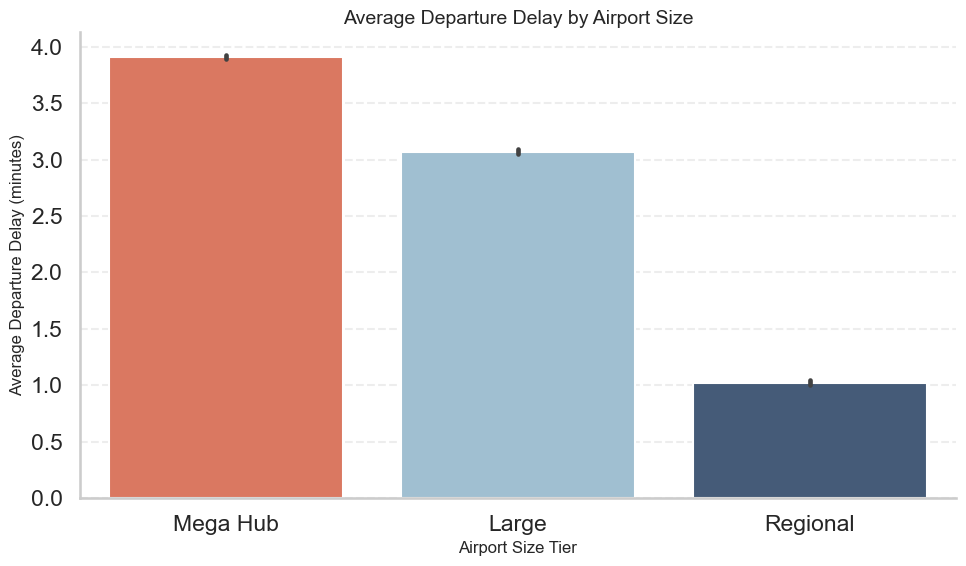

,AIRPORT_SIZE,flights,mean_delay,p90_delay
1,Mega Hub,1648343,3.909600,23.0
0,Large,2007721,3.069677,21.0
2,Regional,1209040,1.023490,16.0


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


airport_stats = (
    df.groupby("ORIGIN_AIRPORT")
      .size()
      .reset_index(name="flight_count")
)

volume_rank = airport_stats.sort_values(
    "flight_count", ascending=False
).reset_index(drop=True)

size_map = {}

for idx, code in enumerate(volume_rank["ORIGIN_AIRPORT"], start=1):

    if idx <= 10:
        size_map[code] = "Mega Hub"

    elif idx <= 50:
        size_map[code] = "Large"

    else:
        size_map[code] = "Regional"


df["AIRPORT_SIZE"] = df["ORIGIN_AIRPORT"].map(size_map).fillna("Regional")


bar_df = df[df["DEPARTURE_DELAY"].between(-10, 60)].copy()

order = ["Mega Hub", "Large", "Regional"]


plt.figure(figsize=(10,6))

sns.barplot(
    data=bar_df,
    x="AIRPORT_SIZE",
    y="DEPARTURE_DELAY",
    order=order,
    estimator="mean",
    palette=["#EE6C4D", "#98C1D9", "#3D5A80"]
)

plt.title("Average Departure Delay by Airport Size", fontsize=14)
plt.xlabel("Airport Size Tier", fontsize=12)
plt.ylabel("Average Departure Delay (minutes)", fontsize=12)

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()

summary = (
    bar_df.groupby("AIRPORT_SIZE", as_index=False)
          .agg(
              flights=("DEPARTURE_DELAY", "size"),
              mean_delay=("DEPARTURE_DELAY", "mean"),
              p90_delay=("DEPARTURE_DELAY", lambda s: s.quantile(0.90))
          )
)

summary["AIRPORT_SIZE"] = pd.Categorical(
    summary["AIRPORT_SIZE"],
    categories=order,
    ordered=True
)

summary = summary.sort_values("AIRPORT_SIZE")

summary